# Quartic OU with white Gaussian noise — the simplest nonlinear example

**Showcases:** the minimal nonlinear stochastic model in the framework — an Ornstein–Uhlenbeck variable with a cubic restoring force, driven by **white** Gaussian noise. A **single** physical field, no Markovian embedding: the MSR-JD diagrammatics act on the bare action directly, so the loop integrals stay cheap and a full **2-loop** correlator over the whole $\tau$ grid runs in seconds. (Contrast `temporal_ou_quartic_colored`, where finite-$\tau_c$ noise doubles the field content and the 2-loop integrals become very expensive.)

$$\dot x = -\mu\,x - \varepsilon\,x^3 + \xi,\qquad \langle\xi(t)\,\xi(t')\rangle = 2D\,\delta(t-t').$$


## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file: a single physical field $x$, white-noise CGF, and the cubic drift. Nothing is embedded or rewritten — what you declare is what the diagrammatics sees. The only fluctuation field is `dx`.

In [2]:
THEORY = 'ou_quartic'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)
print('\nphysical fields:', dd.field_names(model))

────────────────────────────────────────────────────────────────────────
  OU Quartic (white noise)
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : x — variable
Response fields: xt
Parameters     :
    mu = 1.0  (positive)
    eps = 0.02  (positive)
    D = 1.0  (positive)
Mean-field saddle (solved by the pipeline): xstar
Governing eqn  : (Dt+mu)*x[i] = -eps*x[i]^3
Suggested run  : k=2, max_ell=0

The simplest nonlinear stochastic process in the framework: an
Ornstein–Uhlenbeck variable with a cubic restoring nonlinearity, driven by
*white* Gaussian noise,

    dx/dt = -mu*x - eps*x^3 + xi,    <xi(t) xi(t')> = 2 D delta(t - t').

This is the white-noise sibling of ``ou_quartic_colored`` — a SINGLE physical
field, no finite-tau_c Markovian embedding — so every diagram runs on the bare
white-noise system and the loop integrals stay cheap.  At mu>0 the mean-field
saddle is x*=0 (single well); mu<0 is the g

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). We request the fluctuation autocorrelator $C_{xx}(\tau)=\langle\delta x(0)\,\delta x(\tau)\rangle$ via `external_fields=[('dx',1),('dx',1)]`, to **2 loops** (`max_ell=2`). Parameters sit in the mildly-perturbative single-well regime ($\mu>0$, saddle $x^*=0$). The plot is **theory only** — the simulation is added in §3.

In [3]:
cfg = dd.Config(
    k=2, max_ell=2,                          # C_xx(τ): tree + 1-loop + 2-loop
    external_fields=[('dx', 1), ('dx', 1)],  # fluctuation autocorrelator ⟨δx δx⟩
    parameters={'mu': 1.0, 'eps': 0.02, 'D': 1.0},
    tau_max=8.0, tau_step=0.5,
    parallel=False,                          # serial; white noise is cheap, no fork needed
)

theory : 'OU Quartic (white noise)'
k      : 2    max_ell : 2
fields : ['dx']   spatial_dim : 0


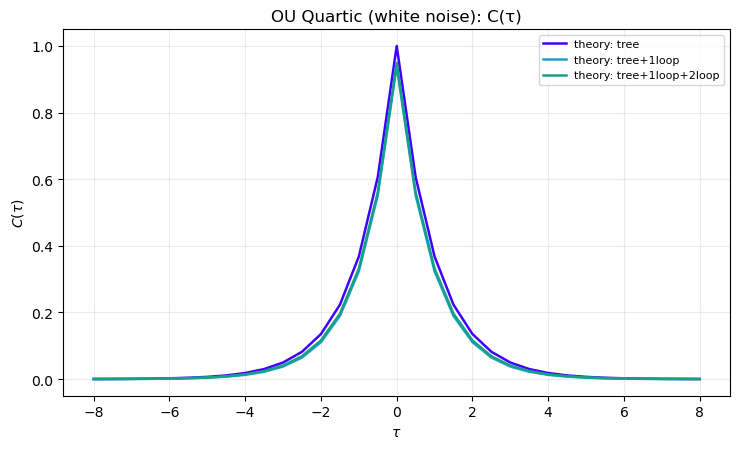

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct Euler–Maruyama integration of the white-noise SDE — written from scratch, no reference to the diagrammatics. We estimate the connected $C_{xx}(\tau)$ from the trajectory and overlay it on the pipeline curve. The output bin is kept **fine** ($\mathrm{dt\_bin}=0.02 \ll 1/\mu$) so the bin-average does not smooth away the equal-time variance — with white noise the process is rough, and a coarse bin would bias $C_{xx}(0)$ low.

sim took 11.2s  (4 runs x T=2e+05)
C_xx(0):  tree = 1.0000   tree+loops = 0.9496   sim = 0.9471 +/- 0.0013


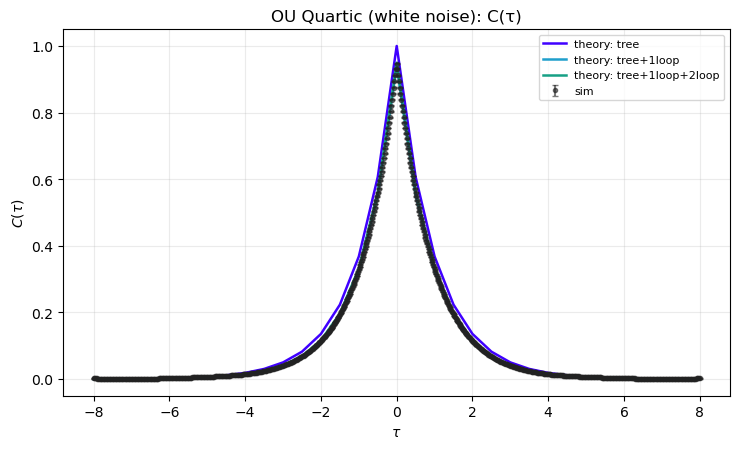

In [5]:
# Independent Euler–Maruyama simulation of the WHITE-noise quartic Langevin —
# written from scratch, NOT the pipeline.
from models.ou_langevin_sim_numba import sim_ou_quartic_numba
from models.cumulant_estimator import estimate_kpoint_slices
fp  = res['_resolved']['parameters']       # same physics as the theory run
# Cast to plain Python floats — under the Sage kernel the resolved params are
# Sage ring elements, which numba's njit cannot type.
mu  = float(fp['mu']); eps = float(fp['eps']); D = float(fp['D'])

# Discretization: dt_sim ≪ relaxation time 1/mu = 1, and a FINE output bin
# dt_bin=0.02 so binning does not bias the equal-time variance (see §3 note).
# Force plain Python int/float on every scalar — under the Sage kernel bare
# literals are Sage ring elements that numba's njit cannot type.
dt_sim, dt_bin = float(0.01), float(0.02)
T_sim          = float(2.0e5)              # ~15-s run
N_RUNS         = int(4)
tau_max        = float(cfg.tau_max)
n_steps        = int(T_sim / dt_sim)
bin_size_steps = int(max(round(float(dt_bin / dt_sim)), 1))
dt_bin_eff     = float(bin_size_steps * dt_sim)
n_bins         = int(n_steps // bin_size_steps)
max_lag_bins   = int(tau_max / dt_bin_eff)
x_init         = float(0.0)                # MF saddle x*=0

# k-aware estimator (matches res['C_tau_slices'] / plot_cumulant for k≥3).
# Single physical field ⇒ every external leg is the same 'dv' field.
k         = int(res['_resolved']['k'])
base      = list(cfg.kpoint_base_lags) if cfg.kpoint_base_lags else [0.0]*(k-1)
base_bins = [int(round(b / dt_bin_eff)) for b in base]
pop_indices = [0]*k
field_types = ['dv']*k

_ = sim_ou_quartic_numba(int(1000), dt_sim, mu, eps, D, x_init,
                         bin_size_steps, int(100), int(0))   # JIT warmup
rng_base = int(np.random.SeedSequence().generate_state(1)[0]) % (2**31)
C_runs = []
t0 = time.perf_counter()
for r in range(N_RUNS):
    x_bins = sim_ou_quartic_numba(n_steps, dt_sim, mu, eps, D, x_init,
                                  bin_size_steps, n_bins, int(rng_base + r))
    tau_sim, Cj = estimate_kpoint_slices(
        dt_bin_eff, pop_indices, field_types, base_bins,
        int(max_lag_bins), voltage_bins=x_bins)            # Cj: (k-1, n_tau)
    C_runs.append(np.asarray(Cj).real)
C_arr = np.array(C_runs)                   # (N_RUNS, k-1, n_tau)
C_sim = C_arr.mean(axis=0)                 # (k-1, n_tau)
C_err = C_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
sim   = {'tau': tau_sim, 'C': C_sim, 'C_err': C_err}
print('sim took %.1fs  (%d runs x T=%.0g)' % (time.perf_counter() - t0,
      N_RUNS, T_sim))

i0 = int(np.argmin(np.abs(np.asarray(res['tau_grid']))))
js = int(np.argmin(np.abs(tau_sim)))
C0_tree = np.real(res['C_tau_by_ell'][0])[i0]
C0_loop = np.real(res['C_tau'])[i0]
print('C_xx(0):  tree = %.4f   tree+loops = %.4f   sim = %.4f +/- %.4f'
      % (C0_tree, C0_loop, C_sim[0][js], C_err[0][js]))
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

## Summary

White Gaussian noise is the native case for MSR-JD diagrammatics — no preprocessing, a single fluctuation field `dx`. The exact linear (tree) equal-time variance is $C_{xx}(0)=D/\mu=1$; the cubic nonlinearity $\varepsilon x^3$ suppresses it, and the loop expansion captures the shift — here tree $1.000 \to$ tree+1-loop $0.940 \to$ tree+2-loop $0.950$, matching the direct simulation ($\approx 0.945$) to $\sim$0.5%. Because there is no auxiliary noise field, the **full 2-loop** correlator over the whole $\tau$ grid evaluates in ~20 s — the same calculation that, with finite-$\tau_c$ colored noise (`temporal_ou_quartic_colored`), blows up by orders of magnitude. Raise `max_ell` for higher loops; raise `eps` / lower `mu` to push the series toward its perturbative edge.